In [1]:
CSV_PATH = "../../results/vggnet16/ALL_vggnet_flipped.csv" 

/var/folders/fr/3yg6c3f55w58dtlsnjcqjmth0000gq/T/ipykernel_94807/3560834908.py:276: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


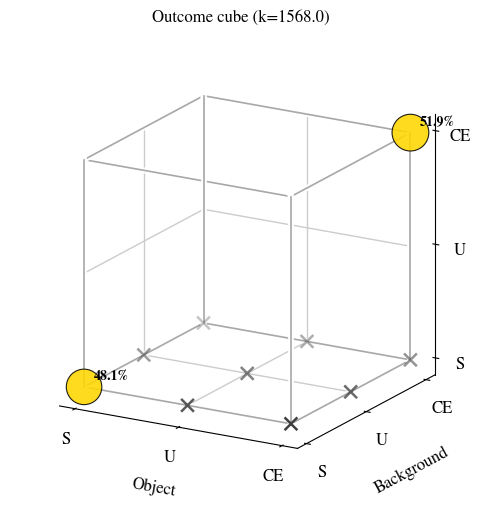

In [2]:
# ============================
# FULL, ONE-CHUNK CODE:
# df (raw) -> summaries (per k) -> clean 3-face cube grid + balls at intersections with %
# ============================

import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from itertools import product
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ---------------------------
# (A) EDIT THESE IF NEEDED
# ---------------------------

INSTANCE_COL = "image"   # image-level triplet id column
TAG_COL      = "tag"     # global/object/background tag
RESULT_COL   = "result"  # result string column
K_COL        = "k"       # budget column

# Forbidden triples (O,B,G) in {"S","U","CE"}.
FORBIDDEN = [
    # Rule 1: G=S but (O,B) not both S
    ("S","U","S"), ("S","CE","S"),
    ("U","S","S"), ("U","U","S"), ("U","CE","S"),
    ("CE","S","S"), ("CE","U","S"), ("CE","CE","S"),
]

# Plot controls
LABEL_ALL     = True
LABEL_MIN_PCT = 0.0     # increase to reduce label clutter, e.g., 2.0
SAVE_PDF      = None    # e.g., "figures/outcome_cube_k0.pdf"

# ---------------------------
# Paper-ish style
# ---------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral", "Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ---------------------------
# (B) LOAD df
# ---------------------------
if "df" not in globals() or df is None:
    if CSV_PATH is None:
        raise ValueError("Either set CSV_PATH or make sure a DataFrame named `df` exists.")
    df = pd.read_csv(CSV_PATH)

# Validate required columns
need = [INSTANCE_COL, TAG_COL, RESULT_COL, K_COL]
missing = [c for c in need if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns: {missing}\nAvailable columns: {list(df.columns)}")

# ---------------------------
# (C) MAP raw tags/results -> (O,B,G) and statuses
# ---------------------------
def tag_to_semantic(tag: str) -> str:
    t = str(tag).strip().lower()
    if t in {"global", "g"}:
        return "G"
    if t in {"fix_nonmask", "nonmask", "object", "obj", "o"}:
        return "O"
    if t in {"fix_mask", "mask", "background", "bg", "b"}:
        return "B"
    return None

def result_to_status(x) -> str:
    s = str(x).strip().lower()
    if "unsat" in s:
        return "S"
    if re.search(r"\bsat\b", s):
        return "CE"
    if "timeout" in s or "unknown" in s:
        return "U"
    return "U"

df2 = df.copy()
df2["sem"] = df2[TAG_COL].apply(tag_to_semantic)
df2 = df2[df2["sem"].isin(["O","B","G"])].copy()
df2["status"] = df2[RESULT_COL].apply(result_to_status)

# ---------------------------
# (D) BUILD summaries: {k: DataFrame(O,B,G,count)}
# ---------------------------
summaries = {}
statuses = ["S", "CE", "U"]
all_patterns = list(product(statuses, statuses, statuses))

for k_val, dkk in df2.groupby(K_COL, dropna=False):
    inst = (
        dkk.pivot_table(index=INSTANCE_COL, columns="sem", values="status", aggfunc="first")
        .reindex(columns=["O","B","G"])
        .fillna("U")
    )

    counts = (
        inst[["O","B","G"]]
        .apply(lambda r: (r["O"], r["B"], r["G"]), axis=1)
        .value_counts()
    )

    summary = pd.DataFrame(all_patterns, columns=["O","B","G"])
    summary["count"] = [int(counts.get(p, 0)) for p in all_patterns]
    summaries[k_val] = summary

# ---------------------------
# (E) PLOT: cube edges + ONLY 3 face grids + balls at intersections with %
# ---------------------------
STATUS = ["S", "U", "CE"]
IDX = {s: i for i, s in enumerate(STATUS)}

def _draw_cube_edges(ax, lo=0.0, hi=2.0, color="0.25", lw=2.2, halo_lw=4.2):
    corners = [
        (lo, lo, lo), (hi, lo, lo), (lo, hi, lo), (hi, hi, lo),
        (lo, lo, hi), (hi, lo, hi), (lo, hi, hi), (hi, hi, hi),
    ]
    edges = [
        (0,1), (0,2), (1,3), (2,3),
        (4,5), (4,6), (5,7), (6,7),
        (0,4), (1,5), (2,6), (3,7),
    ]

    for i, j in edges:
        xs = [corners[i][0], corners[j][0]]
        ys = [corners[i][1], corners[j][1]]
        zs = [corners[i][2], corners[j][2]]

        # halo (white under-stroke)
        ax.plot(xs, ys, zs, color="white", linewidth=halo_lw, alpha=0.95)

        # main stroke
        ax.plot(xs, ys, zs, color=color, linewidth=lw, alpha=0.98)

def _draw_face_grid(ax, face="floor", grid=(0,1,2), color="0.80", lw=1.0):
    """
    Draw a 3x3 grid ONLY on one face:
      - floor: z=0
      - left : x=0
      - back : y=2
    """
    g = list(grid)

    if face == "floor":
        z = 0
        for x in g:
            ax.plot([x, x], [0, 2], [z, z], color=color, linewidth=lw)
        for y in g:
            ax.plot([0, 2], [y, y], [z, z], color=color, linewidth=lw)

    elif face == "left":
        x = 0
        for z in g:
            ax.plot([x, x], [0, 2], [z, z], color=color, linewidth=lw)
        for y in g:
            ax.plot([x, x], [y, y], [0, 2], color=color, linewidth=lw)

    elif face == "back":
        y = 2
        for z in g:
            ax.plot([0, 2], [y, y], [z, z], color=color, linewidth=lw)
        for x in g:
            ax.plot([x, x], [y, y], [0, 2], color=color, linewidth=lw)

def plot_cube_grid_balls(summary_df,
                         k_val=None,
                         forbidden=None,
                         ball_color="gold",
                         forbidden_color="0.25",
                         size_min=70,
                         size_max=700,
                         label_all=True,
                         label_min_pct=0.0,
                         decimals=1,
                         save_pdf=None):

    sdf = summary_df.copy()
    sdf = sdf[sdf["count"] > 0].copy()
    if sdf.empty:
        print("No nonzero patterns to plot.")
        return

    total = float(sdf["count"].sum())
    sdf["pct"] = sdf["count"] / max(total, 1.0) * 100.0

    sdf["x"] = sdf["O"].map(IDX)
    sdf["y"] = sdf["B"].map(IDX)
    sdf["z"] = sdf["G"].map(IDX)

    p = sdf["pct"].to_numpy()
    pmax = max(p.max(), 1e-9)
    sizes = size_min + (size_max - size_min) * (p / pmax)

    fig = plt.figure(figsize=(7.2, 6.0))
    ax = fig.add_subplot(111, projection="3d")

    # cube + only 3 face grids
    
    _draw_face_grid(ax, "floor", color="0.80", lw=1.0)  # z=0
    _draw_face_grid(ax, "left",  color="0.80", lw=1.0)  # x=0
    _draw_face_grid(ax, "back",  color="0.80", lw=1.0)  # y=2

    # balls
    ax.scatter(
            sdf["x"], sdf["y"], sdf["z"],
            s=sizes,
            color=ball_color,
            edgecolor="black",
            linewidths=0.8,
            alpha=0.88,
            depthshade=False
        )
    
    ax.set_proj_type('ortho')
    ax.set_box_aspect((1, 1, 1))

    _draw_cube_edges(ax, color="0.65", lw=1.2)

    # labels (%)
    if label_all:
        lab = sdf[sdf["pct"] >= label_min_pct]
    else:
        lab = sdf.sort_values("pct", ascending=False).head(6)

    for _, r in lab.iterrows():
        ax.text(r["x"] + 0.06, r["y"] + 0.06, r["z"] + 0.06,
                f'{r["pct"]:.{decimals}f}%',
                fontsize=10, weight="bold")

    # forbidden crosses
    if forbidden:
        fx, fy, fz = [], [], []
        for (o, b, g) in forbidden:
            if o in IDX and b in IDX and g in IDX:
                fx.append(IDX[o]); fy.append(IDX[b]); fz.append(IDX[g])
        if fx:
            ax.scatter(fx, fy, fz,
                       marker="x",
                       s=85,
                       color=forbidden_color,
                       linewidths=1.8)

    # axes
    ax.set_xticks([0, 1, 2]); ax.set_xticklabels(STATUS)
    ax.set_yticks([0, 1, 2]); ax.set_yticklabels(STATUS)
    ax.set_zticks([0, 1, 2]); ax.set_zticklabels(STATUS)

    ax.set_xlabel("Object", labelpad=10)
    ax.set_ylabel("Background", labelpad=12)
    ax.set_zlabel("Global", labelpad=8)

    ax.set_xlim(-0.15, 2.15)
    ax.set_ylim(-0.15, 2.15)
    ax.set_zlim(-0.15, 2.15)

    ax.view_init(elev=18, azim=-60)

    # remove pane shading (no cube fill color)
    ax.xaxis.pane.set_alpha(0.0)
    ax.yaxis.pane.set_alpha(0.0)
    ax.zaxis.pane.set_alpha(0.0)
    ax.grid(False)

    if k_val is not None:
        ax.set_title(f"Outcome cube (k={k_val})", pad=10)

    plt.tight_layout()
    if save_pdf:
        plt.savefig(save_pdf, bbox_inches="tight")
        print("Saved:", save_pdf)
    plt.show()

# ---------------------------
# (F) RUN
# ---------------------------
k0 = sorted(summaries.keys(), key=lambda x: (pd.isna(x), x))[0]

plot_cube_grid_balls(
    summaries[k0],
    k_val=k0,
    forbidden=FORBIDDEN,     # or None
    label_all=LABEL_ALL,
    label_min_pct=LABEL_MIN_PCT,
    save_pdf=SAVE_PDF
)

In [3]:
print("rows:", len(df))
print("columns:", list(df.columns))
print("unique images:", len(pd.unique(df['image'])))
print("unique vnnlib files:", len(pd.unique(df['vnnlib'])))
print("models:", pd.unique(df['model']))
print("k values:", pd.unique(df['k']))

df2 = df[df['k'] == 50176.]
print("rows at k=50176:", len(df2))

print("unique images at k=50176:", len(pd.unique(df2['image'])))
print("unique vnnlib files at k=50176:", len(pd.unique(df2['vnnlib'])))
print(df2.groupby('tag').size())

rows: 3261
columns: ['instance_id', 'onnx', 'vnnlib', 'timeout', 'result', 'lb_minus_rhs', 'domains_visited', 'bab_time', 'all_time', 'init_unstable', 'image', 'tag', 'segment_index', 'k', 'eps', 'model', 'is_global', 'score', 'bbox', 'num_changed', 'num_fixed', 'total', 'percent_changed', 'pattern']
unique images: 183
unique vnnlib files: 3259
models: ['vgg16-7' nan]
k values: [ 1568. 12544.  3136. 25088. 50176.  6272.    nan]
rows at k=50176: 543
unique images at k=50176: 181
unique vnnlib files at k=50176: 543
tag
fix_mask       181
fix_nonmask    181
global         181
dtype: int64


50176.0
     O   B   G  count        pct
0    S   S   S     13   7.182320
1    S   S  CE      0   0.000000
2    S   S   U     28  15.469613
3    S  CE   S      0   0.000000
4    S  CE  CE      0   0.000000
5    S  CE   U      0   0.000000
6    S   U   S      0   0.000000
7    S   U  CE      0   0.000000
8    S   U   U     17   9.392265
9   CE   S   S      0   0.000000
10  CE   S  CE      0   0.000000
11  CE   S   U      0   0.000000
12  CE  CE   S      0   0.000000
13  CE  CE  CE     95  52.486188
14  CE  CE   U      0   0.000000
15  CE   U   S      0   0.000000
16  CE   U  CE      0   0.000000
17  CE   U   U      0   0.000000
18   U   S   S      0   0.000000
19   U   S  CE      0   0.000000
20   U   S   U     27  14.917127
21   U  CE   S      0   0.000000
22   U  CE  CE      0   0.000000
23   U  CE   U      0   0.000000
24   U   U   S      0   0.000000
25   U   U  CE      1   0.552486
26   U   U   U      0   0.000000
Saved: imagenet_gamma.pdf


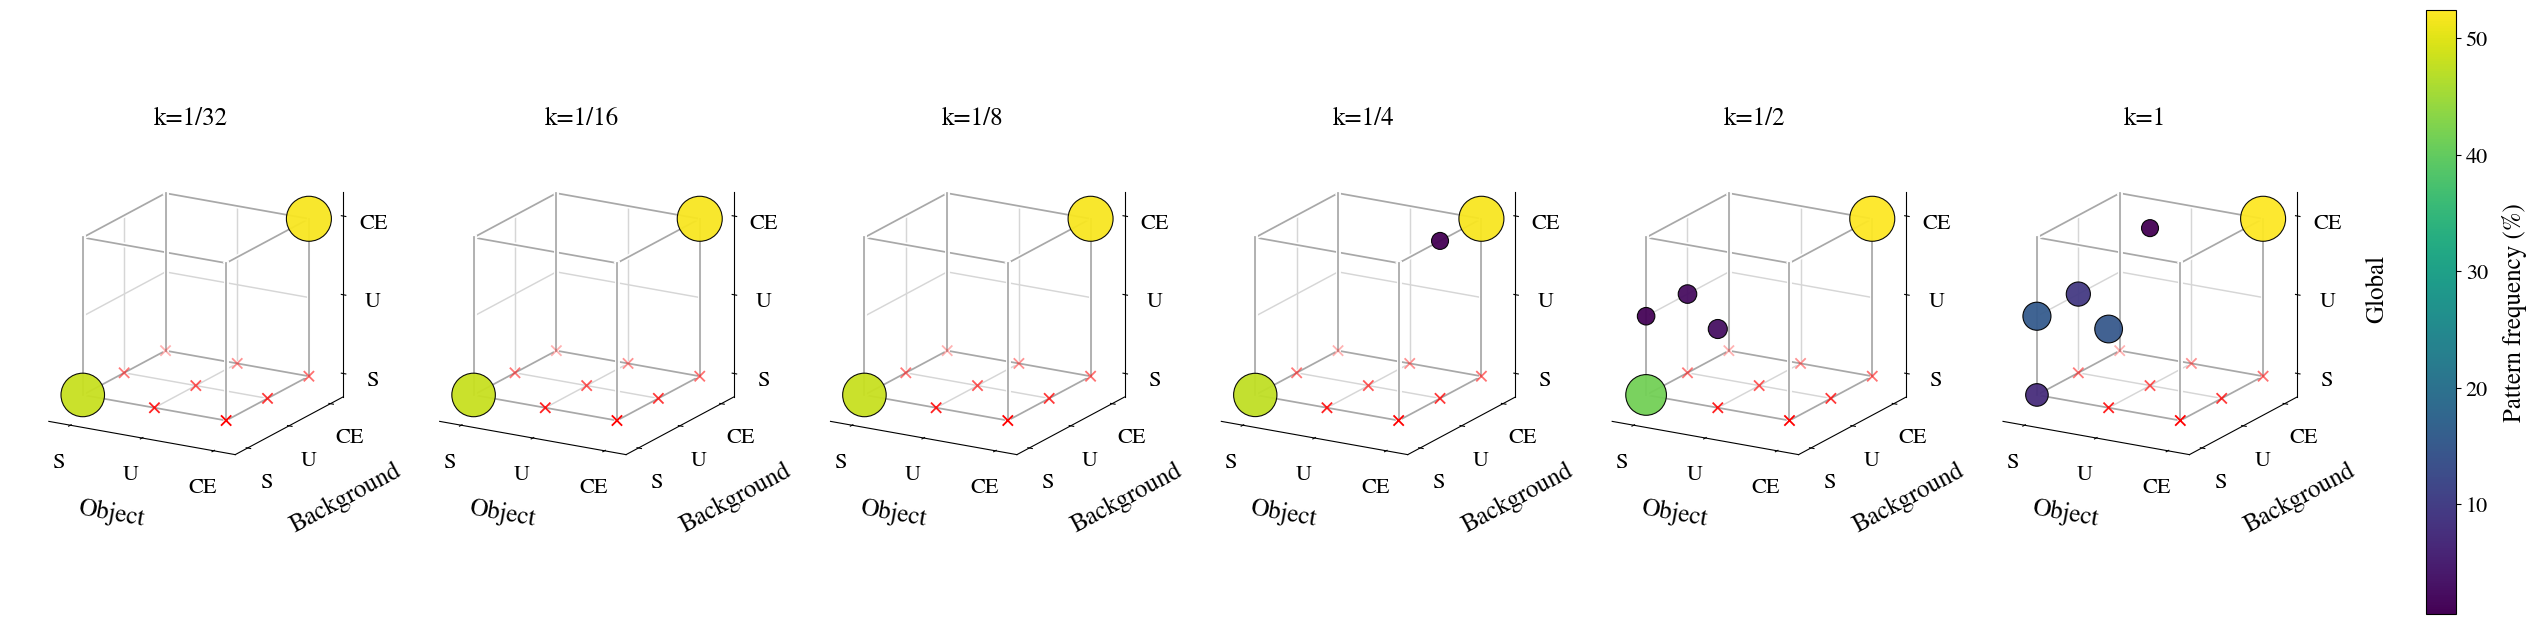

In [4]:
# ============================
# FULL, ONE-CHUNK CODE (v3):
# 1) Plots moved UP (top/bottom margins + optional y-shift)
# 2) More visible labels (bigger fonts + more labelpad + less clipping)
# 3) NO % text on balls: use colormap shading + a single colorbar (shared)
#    - ball size still encodes frequency (pct) for readability
#    - ball color encodes pct (shade) with a colorbar
# ============================

import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from itertools import product
from fractions import Fraction
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ---------------------------
# (A) EDIT THESE IF NEEDED
# ---------------------------
INSTANCE_COL = "image"   # group the 3 tag rows into one triplet per image
TAG_COL      = "tag"
RESULT_COL   = "result"
K_COL        = "k"

FORBIDDEN = [
    ("S","U","S"), ("S","CE","S"),
    ("U","S","S"), ("U","U","S"), ("U","CE","S"),
    ("CE","S","S"), ("CE","U","S"), ("CE","CE","S"),
]

SAVE_PDF = "imagenet_gamma.pdf"   # e.g., "figures/outcome_cubes_all_k_row_colorbar.pdf"

# ---------------------------
# Paper-ish style (LaTeX/PDF friendly)
# ---------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral", "Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "figure.titlesize": 18,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ---------------------------
# Helper: show k like 1, 1/2, 1/4, ..., 1/32
# ---------------------------
FULL_K = 50176
K_TO_LABEL = {
    50176: "1",
    25088: "1/2",
    12544: "1/4",
    6272:  "1/8",
    3136:  "1/16",
    1568:  "1/32",
}

def pretty_k(k):
    if pd.isna(k):
        return "k=NA"
    try:
        kk = int(round(float(k)))
    except Exception:
        return f"k={k}"

    if kk in K_TO_LABEL:
        return f"k={K_TO_LABEL[kk]}"

    if FULL_K and kk > 0:
        fr = Fraction(kk, FULL_K).limit_denominator(64)
        if abs(float(fr) - kk / float(FULL_K)) < 1e-9:
            if fr.numerator == 1:
                return "k=1" if fr.denominator == 1 else f"k=1/{fr.denominator}"
            return f"k={fr.numerator}/{fr.denominator}"

    return f"k={kk}"

# ---------------------------
# (B) LOAD df
# ---------------------------
if "df" not in globals() or df is None:
    if "CSV_PATH" not in globals() or CSV_PATH is None:
        raise ValueError("Either set CSV_PATH or make sure a DataFrame named `df` exists.")
    df = pd.read_csv(CSV_PATH)

need = [INSTANCE_COL, TAG_COL, RESULT_COL, K_COL]
missing = [c for c in need if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns: {missing}\nAvailable columns: {list(df.columns)}")

# ---------------------------
# (C) MAP tags/results -> (O,B,G) and statuses
# ---------------------------
def tag_to_semantic(tag: str) -> str:
    t = str(tag).strip().lower()
    if t in {"global", "g"}:
        return "G"
    if t in {"fix_nonmask", "nonmask", "object", "obj", "o"}:
        return "O"
    if t in {"fix_mask", "mask", "background", "bg", "b"}:
        return "B"
    return None

def result_to_status(x) -> str:
    s = str(x).strip().lower()
    if "unsat" in s:
        return "S"
    if re.search(r"\bsat\b", s):
        return "CE"
    if "timeout" in s or "unknown" in s:
        return "U"
    return "U"

df2 = df.copy()
df2["sem"] = df2[TAG_COL].apply(tag_to_semantic)
df2 = df2[df2["sem"].isin(["O","B","G"])].copy()
df2["status"] = df2[RESULT_COL].apply(result_to_status)

# ---------------------------
# (D) BUILD summaries: {k: DataFrame(O,B,G,count,pct)}
# and collect global pct range for a shared colorbar
# ---------------------------
summaries = {}
statuses = ["S", "CE", "U"]
all_patterns = list(product(statuses, statuses, statuses))

global_pcts = []

for k_val, dkk in df2.groupby(K_COL, dropna=False):
    inst = (
        dkk.pivot_table(index=INSTANCE_COL, columns="sem", values="status", aggfunc="first")
        .reindex(columns=["O","B","G"])
        .fillna("U")
    )

    counts = (
        inst[["O","B","G"]]
        .apply(lambda r: (r["O"], r["B"], r["G"]), axis=1)
        .value_counts()
    )

    summary = pd.DataFrame(all_patterns, columns=["O","B","G"])
    summary["count"] = [int(counts.get(p, 0)) for p in all_patterns]

    tot = float(summary["count"].sum())
    summary["pct"] = (summary["count"] / max(tot, 1.0)) * 100.0

    # store non-zero pct values for global scaling
    global_pcts.extend(summary.loc[summary["count"] > 0, "pct"].tolist())

    summaries[k_val] = summary

if not summaries:
    raise ValueError("No k values found in summaries.")

# Shared color normalization across ALL panels (consistent colors)
if len(global_pcts) == 0:
    vmin, vmax = 0.0, 1.0
else:
    vmin, vmax = float(min(global_pcts)), float(max(global_pcts))
    if abs(vmax - vmin) < 1e-12:
        vmax = vmin + 1.0

# Choose colormap (paper-friendly). Change if you want.
CMAP = mpl.cm.viridis
NORM = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# ---------------------------
# (E) DRAW HELPERS
# ---------------------------
STATUS = ["S", "U", "CE"]
IDX = {s: i for i, s in enumerate(STATUS)}

def _draw_cube_edges(ax, lo=0.0, hi=2.0, color="0.25", lw=2.4, halo_lw=4.6):
    corners = [
        (lo, lo, lo), (hi, lo, lo), (lo, hi, lo), (hi, hi, lo),
        (lo, lo, hi), (hi, lo, hi), (lo, hi, hi), (hi, hi, hi),
    ]
    edges = [
        (0,1), (0,2), (1,3), (2,3),
        (4,5), (4,6), (5,7), (6,7),
        (0,4), (1,5), (2,6), (3,7),
    ]
    for i, j in edges:
        xs = [corners[i][0], corners[j][0]]
        ys = [corners[i][1], corners[j][1]]
        zs = [corners[i][2], corners[j][2]]
        ax.plot(xs, ys, zs, color="white", linewidth=halo_lw, alpha=0.95)
        ax.plot(xs, ys, zs, color=color, linewidth=lw, alpha=0.98)

def _draw_face_grid(ax, face="floor", grid=(0,1,2), color="0.84", lw=1.05):
    g = list(grid)
    if face == "floor":
        z = 0
        for x in g:
            ax.plot([x, x], [0, 2], [z, z], color=color, linewidth=lw)
        for y in g:
            ax.plot([0, 2], [y, y], [z, z], color=color, linewidth=lw)
    elif face == "left":
        x = 0
        for z in g:
            ax.plot([x, x], [0, 2], [z, z], color=color, linewidth=lw)
        for y in g:
            ax.plot([x, x], [y, y], [0, 2], color=color, linewidth=lw)
    elif face == "back":
        y = 2
        for z in g:
            ax.plot([0, 2], [y, y], [z, z], color=color, linewidth=lw)
        for x in g:
            ax.plot([x, x], [y, y], [0, 2], color=color, linewidth=lw)

def plot_cube_grid_balls_on_ax(
    ax,
    summary_df,
    k_val=None,
    forbidden=None,
    cmap=CMAP,
    norm=NORM,
    forbidden_color="red",
    forbidden_s=55,        # smaller x
    forbidden_lw=1.3,      # thinner x
    size_min=140,
    size_max=1050,
    view=(18, -60),
    title_fs=18,
    axis_fs=16,
    label_fs=18,
    show_axis_labels=True,
):
    sdf = summary_df.copy()
    sdf = sdf[sdf["count"] > 0].copy()
    if sdf.empty:
        ax.set_axis_off()
        if k_val is not None:
            ax.set_title(f"{pretty_k(k_val)} (empty)", fontsize=title_fs, pad=2)
        return None

    sdf["x"] = sdf["O"].map(IDX)
    sdf["y"] = sdf["B"].map(IDX)
    sdf["z"] = sdf["G"].map(IDX)

    p = sdf["pct"].to_numpy()
    pmax = max(float(p.max()), 1e-9)
    sizes = size_min + (size_max - size_min) * (p / pmax)

    # Colors from pct -> colormap
    colors = cmap(norm(p))

    _draw_face_grid(ax, "floor")
    _draw_face_grid(ax, "left")
    _draw_face_grid(ax, "back")

    sc = ax.scatter(
        sdf["x"], sdf["y"], sdf["z"],
        s=sizes,
        c=p,                 # color value for colorbar
        cmap=cmap,
        norm=norm,
        edgecolor="black",
        linewidths=0.8,
        alpha=0.95,          # keep vibrant
        depthshade=True,     # <-- shading for 3D appearance
        zorder=3,
    )

    ax.set_proj_type("ortho")
    ax.set_box_aspect((1, 1, 1))
    _draw_cube_edges(ax, color="0.65", lw=1.25, halo_lw=3.6)

    # forbidden crosses (smaller + red)
    if forbidden:
        fx, fy, fz = [], [], []
        for (o, b, g) in forbidden:
            if o in IDX and b in IDX and g in IDX:
                fx.append(IDX[o]); fy.append(IDX[b]); fz.append(IDX[g])
        if fx:
            ax.scatter(
                fx, fy, fz,
                marker="x",
                s=forbidden_s,
                color=forbidden_color,
                linewidths=forbidden_lw,
                zorder=8,
            )

    # ticks
    ax.set_xticks([0, 1, 2]); ax.set_xticklabels(STATUS, fontsize=axis_fs)
    ax.set_yticks([0, 1, 2]); ax.set_yticklabels(STATUS, fontsize=axis_fs)
    ax.set_zticks([0, 1, 2]); ax.set_zticklabels(STATUS, fontsize=axis_fs)

    # Make tick labels breathe a bit (helps visibility)
    ax.tick_params(axis="x", pad=6)
    ax.tick_params(axis="y", pad=6)
    ax.tick_params(axis="z", pad=6)

    # Axis labels
    if show_axis_labels:
        ax.set_xlabel("Object", labelpad=18, fontsize=label_fs)
        ax.set_ylabel("Background", labelpad=20, fontsize=label_fs)
        ax.set_zlabel("Global", labelpad=16, fontsize=label_fs)

    # Expand limits slightly so labels don't clip
    ax.set_xlim(-0.30, 2.30)
    ax.set_ylim(-0.30, 2.30)
    ax.set_zlim(-0.30, 2.30)

    ax.view_init(elev=view[0], azim=view[1])

    ax.xaxis.pane.set_alpha(0.0)
    ax.yaxis.pane.set_alpha(0.0)
    ax.zaxis.pane.set_alpha(0.0)
    ax.grid(False)

    if k_val is not None:
        # title closer to cube
        ax.set_title(pretty_k(k_val), fontsize=title_fs, pad=2)

    return sc

# ---------------------------
# (F) RUN: ONE ROW OF SUBPLOTS (all k) + shared colorbar
# ---------------------------
k_list = sorted(summaries.keys(), key=lambda x: (pd.isna(x), x))
n = len(k_list)

# Slightly tighter panel width; leave extra right space for colorbar
panel_w = 4.5
fig_w = panel_w * n + 1.3   # + space for colorbar
fig_h = 6.2
fig = plt.figure(figsize=(fig_w, fig_h))

# Draw cubes
last_scatter = None
for i, k_val in enumerate(k_list, start=1):
    ax = fig.add_subplot(1, n, i, projection="3d")
    last_scatter = plot_cube_grid_balls_on_ax(
        ax,
        summaries[k_val],
        k_val=k_val,
        forbidden=FORBIDDEN,
        cmap=CMAP,
        norm=NORM,
        forbidden_color="red",
        forbidden_s=55,
        forbidden_lw=1.3,
        size_min=140,
        size_max=1050,
        view=(18, -60),
        title_fs=18,
        axis_fs=16,
        label_fs=18,
        show_axis_labels=True,
    )
print(k_val)
print(summaries[k_val])

# Move plots UP + make them closer
plt.subplots_adjust(
    left=0.02,
    right=0.90,   # reserve space for colorbar
    top=0.985,
    bottom=0.01,
    wspace=0.08   # smaller = closer panels
)

# Optional: shift ALL axes upward a bit more (uncomment if you still want "higher")
# dy = 0.02
# for ax in fig.axes:
#     pos = ax.get_position()
#     ax.set_position([pos.x0, pos.y0 + dy, pos.width, pos.height])

# Shared colorbar (pct)
if last_scatter is not None:
    sm = mpl.cm.ScalarMappable(norm=NORM, cmap=CMAP)
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=fig.axes,
        fraction=0.03,
        pad=0.04
    )
    cbar.set_label("Pattern frequency (%)", fontsize=18, labelpad=10)
    cbar.ax.tick_params(labelsize=16)

if SAVE_PDF:
    plt.savefig(SAVE_PDF, bbox_inches="tight")
    print("Saved:", SAVE_PDF)

plt.show()

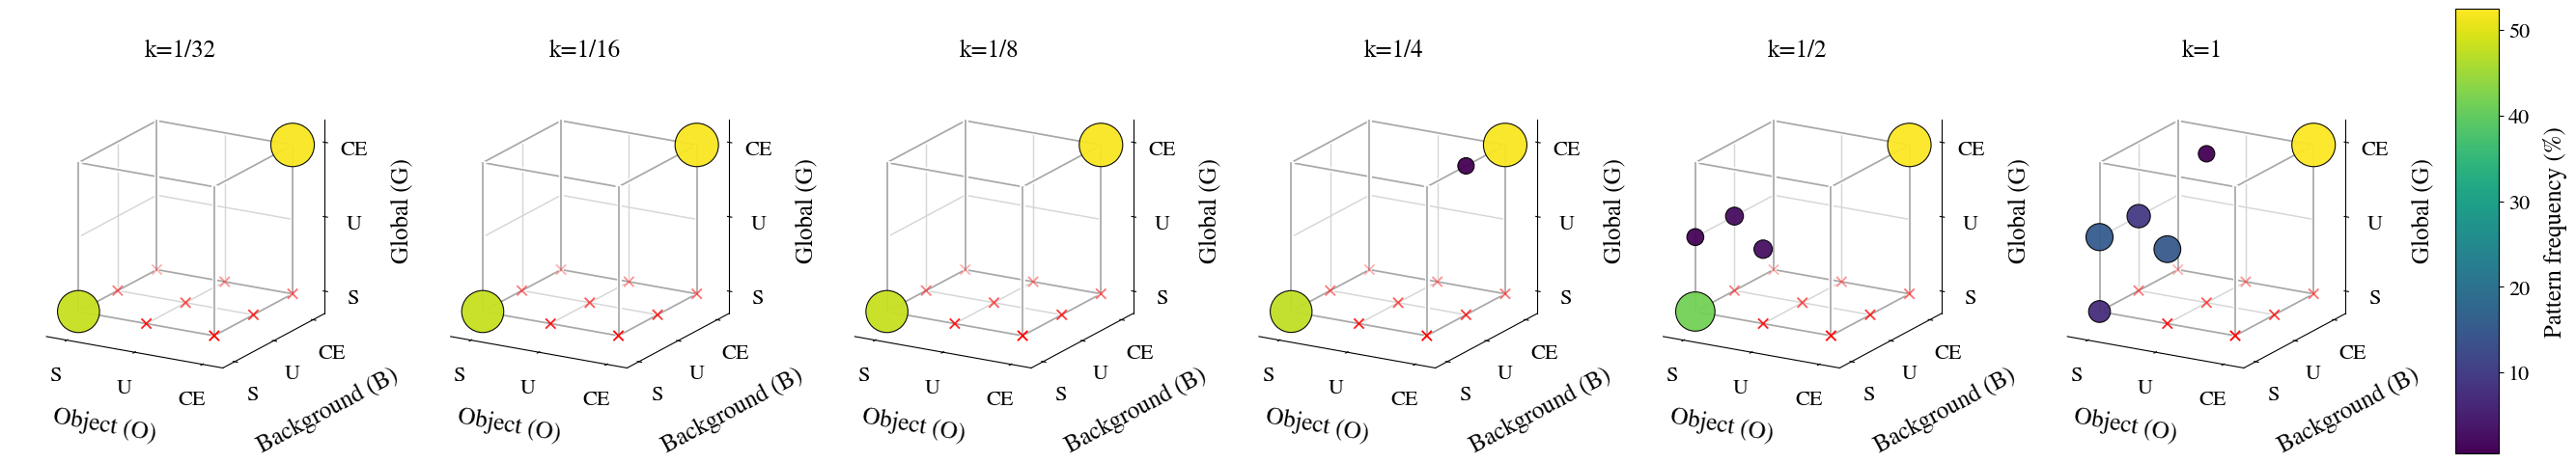

In [5]:
# ============================
# FULL, ONE-CHUNK CODE (v4):
# SAME plot shape/layout as before
# - Upper plots
# - Visible labels
# - Shaded balls + shared colorbar (moved right)
# - Better colormap (paper-friendly, high contrast)
# ============================

import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from itertools import product
from fractions import Fraction
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ---------------------------
# (A) EDIT THESE IF NEEDED
# ---------------------------
INSTANCE_COL = "image"   # group the 3 tag rows into one triplet per image
TAG_COL      = "tag"
RESULT_COL   = "result"
K_COL        = "k"

FORBIDDEN = [
    ("S","U","S"), ("S","CE","S"),
    ("U","S","S"), ("U","U","S"), ("U","CE","S"),
    ("CE","S","S"), ("CE","U","S"), ("CE","CE","S"),
]

SAVE_PDF = None   # e.g., "figures/outcome_cubes_all_k_row_colorbar.pdf"

# ---------------------------
# Paper-ish style (LaTeX/PDF friendly)
# ---------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral", "Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "figure.titlesize": 18,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ---------------------------
# Helper: show k like 1, 1/2, 1/4, ..., 1/32
# ---------------------------
FULL_K = 50176
K_TO_LABEL = {
    50176: "1",
    25088: "1/2",
    12544: "1/4",
    6272:  "1/8",
    3136:  "1/16",
    1568:  "1/32",
}

def pretty_k(k):
    if pd.isna(k):
        return "k=NA"
    try:
        kk = int(round(float(k)))
    except Exception:
        return f"k={k}"
    if kk in K_TO_LABEL:
        return f"k={K_TO_LABEL[kk]}"
    return f"k={kk}"

# ---------------------------
# (B) LOAD df
# ---------------------------
if "df" not in globals() or df is None:
    if "CSV_PATH" not in globals() or CSV_PATH is None:
        raise ValueError("Either set CSV_PATH or make sure a DataFrame named `df` exists.")
    df = pd.read_csv(CSV_PATH)

need = [INSTANCE_COL, TAG_COL, RESULT_COL, K_COL]
missing = [c for c in need if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns: {missing}\nAvailable columns: {list(df.columns)}")

# ---------------------------
# (C) MAP tags/results -> (O,B,G) and statuses
# ---------------------------
def tag_to_semantic(tag: str) -> str:
    t = str(tag).strip().lower()
    if t in {"global", "g"}:
        return "G"
    if t in {"fix_nonmask", "nonmask", "object", "obj", "o"}:
        return "O"
    if t in {"fix_mask", "mask", "background", "bg", "b"}:
        return "B"
    return None

def result_to_status(x) -> str:
    s = str(x).strip().lower()
    if "unsat" in s:
        return "S"
    if re.search(r"\bsat\b", s):
        return "CE"
    if "timeout" in s or "unknown" in s:
        return "U"
    return "U"

df2 = df.copy()
df2["sem"] = df2[TAG_COL].apply(tag_to_semantic)
df2 = df2[df2["sem"].isin(["O","B","G"])].copy()
df2["status"] = df2[RESULT_COL].apply(result_to_status)

# ---------------------------
# (D) BUILD summaries + collect pct range for shared colorbar
# ---------------------------
summaries = {}
statuses = ["S", "CE", "U"]
all_patterns = list(product(statuses, statuses, statuses))

global_pcts = []

for k_val, dkk in df2.groupby(K_COL, dropna=False):
    inst = (
        dkk.pivot_table(index=INSTANCE_COL, columns="sem", values="status", aggfunc="first")
        .reindex(columns=["O","B","G"])
        .fillna("U")
    )

    counts = (
        inst[["O","B","G"]]
        .apply(lambda r: (r["O"], r["B"], r["G"]), axis=1)
        .value_counts()
    )

    summary = pd.DataFrame(all_patterns, columns=["O","B","G"])
    summary["count"] = [int(counts.get(p, 0)) for p in all_patterns]

    tot = float(summary["count"].sum())
    summary["pct"] = (summary["count"] / max(tot, 1.0)) * 100.0

    global_pcts.extend(summary.loc[summary["count"] > 0, "pct"].tolist())
    summaries[k_val] = summary

if not summaries:
    raise ValueError("No k values found in summaries.")

if len(global_pcts) == 0:
    vmin, vmax = 0.0, 1.0
else:
    vmin, vmax = float(min(global_pcts)), float(max(global_pcts))
    if abs(vmax - vmin) < 1e-12:
        vmax = vmin + 1.0

# ---------------------------
# BETTER COLOR (keep everything else same)
# Options (paper-friendly):
# - mpl.cm.magma   (high contrast, very readable)
# - mpl.cm.viridis (classic)
# - mpl.cm.cividis (colorblind-safe, softer)
# ---------------------------
CMAP = mpl.cm.viridis
NORM = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# ---------------------------
# (E) DRAW HELPERS
# ---------------------------
STATUS = ["S", "U", "CE"]
IDX = {s: i for i, s in enumerate(STATUS)}

def _draw_cube_edges(ax, lo=0.0, hi=2.0, color="0.25", lw=2.4, halo_lw=4.6):
    corners = [
        (lo, lo, lo), (hi, lo, lo), (lo, hi, lo), (hi, hi, lo),
        (lo, lo, hi), (hi, lo, hi), (lo, hi, hi), (hi, hi, hi),
    ]
    edges = [
        (0,1), (0,2), (1,3), (2,3),
        (4,5), (4,6), (5,7), (6,7),
        (0,4), (1,5), (2,6), (3,7),
    ]
    for i, j in edges:
        xs = [corners[i][0], corners[j][0]]
        ys = [corners[i][1], corners[j][1]]
        zs = [corners[i][2], corners[j][2]]
        ax.plot(xs, ys, zs, color="white", linewidth=halo_lw, alpha=0.95)
        ax.plot(xs, ys, zs, color=color, linewidth=lw, alpha=0.98)

def _draw_face_grid(ax, face="floor", grid=(0,1,2), color="0.84", lw=1.05):
    g = list(grid)
    if face == "floor":
        z = 0
        for x in g:
            ax.plot([x, x], [0, 2], [z, z], color=color, linewidth=lw)
        for y in g:
            ax.plot([0, 2], [y, y], [z, z], color=color, linewidth=lw)
    elif face == "left":
        x = 0
        for z in g:
            ax.plot([x, x], [0, 2], [z, z], color=color, linewidth=lw)
        for y in g:
            ax.plot([x, x], [y, y], [0, 2], color=color, linewidth=lw)
    elif face == "back":
        y = 2
        for z in g:
            ax.plot([0, 2], [y, y], [z, z], color=color, linewidth=lw)
        for x in g:
            ax.plot([x, x], [y, y], [0, 2], color=color, linewidth=lw)

def plot_cube_grid_balls_on_ax(
    ax,
    summary_df,
    k_val=None,
    forbidden=None,
    cmap=CMAP,
    norm=NORM,
    forbidden_color="red",
    forbidden_s=55,
    forbidden_lw=1.3,
    size_min=140,
    size_max=1050,
    view=(18, -60),
    title_fs=18,
    axis_fs=16,
    label_fs=18,
    show_axis_labels=True,
):
    sdf = summary_df.copy()
    sdf = sdf[sdf["count"] > 0].copy()
    if sdf.empty:
        ax.set_axis_off()
        if k_val is not None:
            ax.set_title(f"{pretty_k(k_val)} (empty)", fontsize=title_fs, pad=2)
        return None

    sdf["x"] = sdf["O"].map(IDX)
    sdf["y"] = sdf["B"].map(IDX)
    sdf["z"] = sdf["G"].map(IDX)

    p = sdf["pct"].to_numpy()
    pmax = max(float(p.max()), 1e-9)
    sizes = size_min + (size_max - size_min) * (p / pmax)

    _draw_face_grid(ax, "floor")
    _draw_face_grid(ax, "left")
    _draw_face_grid(ax, "back")

    sc = ax.scatter(
        sdf["x"], sdf["y"], sdf["z"],
        s=sizes,
        c=p,
        cmap=cmap,
        norm=norm,
        edgecolor="black",
        linewidths=0.8,
        alpha=0.95,
        depthshade=True,   # shaded spheres
        zorder=3,
    )

    ax.set_proj_type("ortho")
    ax.set_box_aspect((1, 1, 1))
    _draw_cube_edges(ax, color="0.65", lw=1.25, halo_lw=3.6)

    # forbidden crosses
    if forbidden:
        fx, fy, fz = [], [], []
        for (o, b, g) in forbidden:
            if o in IDX and b in IDX and g in IDX:
                fx.append(IDX[o]); fy.append(IDX[b]); fz.append(IDX[g])
        if fx:
            ax.scatter(
                fx, fy, fz,
                marker="x",
                s=forbidden_s,
                color=forbidden_color,
                linewidths=forbidden_lw,
                zorder=8,
            )

    ax.set_xticks([0, 1, 2]); ax.set_xticklabels(STATUS, fontsize=axis_fs)
    ax.set_yticks([0, 1, 2]); ax.set_yticklabels(STATUS, fontsize=axis_fs)
    ax.set_zticks([0, 1, 2]); ax.set_zticklabels(STATUS, fontsize=axis_fs)

    ax.tick_params(axis="x", pad=6)
    ax.tick_params(axis="y", pad=6)
    ax.tick_params(axis="z", pad=6)

    if show_axis_labels:
        ax.set_xlabel("Object (O)", labelpad=18, fontsize=label_fs)
        ax.set_ylabel("Background (B)", labelpad=20, fontsize=label_fs)
        ax.set_zlabel("Global (G)", labelpad=16, fontsize=label_fs)

    ax.set_xlim(-0.30, 2.30)
    ax.set_ylim(-0.30, 2.30)
    ax.set_zlim(-0.30, 2.30)

    ax.view_init(elev=view[0], azim=view[1])

    ax.xaxis.pane.set_alpha(0.0)
    ax.yaxis.pane.set_alpha(0.0)
    ax.zaxis.pane.set_alpha(0.0)
    ax.grid(False)

    if k_val is not None:
        ax.set_title(pretty_k(k_val), fontsize=title_fs, pad=2)

    return sc

# ---------------------------
# (F) RUN: ONE ROW OF SUBPLOTS (all k) + shared colorbar
# KEEP SHAPE THE SAME
# ---------------------------
k_list = sorted(summaries.keys(), key=lambda x: (pd.isna(x), x))
n = len(k_list)

# SAME shape logic as before; just reserve space for colorbar by 'right'
panel_w = 4.5
fig_w = panel_w * n + 1.3
fig_h = 7.2
fig = plt.figure(figsize=(fig_w, fig_h))

last_scatter = None
for i, k_val in enumerate(k_list, start=1):
    ax = fig.add_subplot(1, n, i, projection="3d")
    last_scatter = plot_cube_grid_balls_on_ax(
        ax,
        summaries[k_val],
        k_val=k_val,
        forbidden=FORBIDDEN,
        cmap=CMAP,
        norm=NORM,
        forbidden_color="red",
        forbidden_s=55,
        forbidden_lw=1.3,
        size_min=140,
        size_max=1050,
        view=(18, -60),
        title_fs=18,
        axis_fs=16,
        label_fs=18,
        show_axis_labels=True,
    )

# SAME layout feel; upper + tight; do NOT distort subplot geometry
plt.subplots_adjust(
    left=0.02,
    right=0.885,   # keep panels same; space on the right for colorbar
    top=0.985,
    bottom=0.01,
    wspace=0.18
)

# ---- COLORBAR moved a bit to the right (without changing plot shape)
# Create a dedicated axis for colorbar: [left, bottom, width, height]
# Increase "left" to move it further right.
cax = fig.add_axes([0.915, 0.18, 0.016, 0.64])  # <-- moved right vs before

sm = mpl.cm.ScalarMappable(norm=NORM, cmap=CMAP)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Pattern frequency (%)", fontsize=18, labelpad=10)
cbar.ax.tick_params(labelsize=16)

if SAVE_PDF:
    plt.savefig(SAVE_PDF, bbox_inches="tight")
    print("Saved:", SAVE_PDF)

plt.show()

In [6]:
import re
import pandas as pd
from itertools import product

# ----------------------------
# Choose your instance column
# ----------------------------
INSTANCE_COL = "image"    # one triplet per image, not per tag-specific vnnlib

# ----------------------------
# Mapping functions
# ----------------------------
def tag_to_semantic(tag: str) -> str:
    t = str(tag).strip().lower()
    if t in {"global", "g"}:
        return "G"
    if t in {"fix_nonmask", "nonmask", "object", "obj", "o"}:
        return "O"
    if t in {"fix_mask", "mask", "background", "bg", "b"}:
        return "B"
    return None

def result_to_status(x) -> str:
    s = str(x).strip().lower()
    if "unsat" in s:
        return "S"
    if re.search(r"\bsat\b", s):
        return "CE"
    if "timeout" in s or "unknown" in s:
        return "U"
    return "U"

# ----------------------------
# Prepare dataframe
# ----------------------------
df2 = df.copy()
df2["sem"] = df2["tag"].apply(tag_to_semantic)
df2 = df2[df2["sem"].isin(["O","B","G"])].copy()
df2["status"] = df2["result"].apply(result_to_status)

# ----------------------------
# 27 patterns
# ----------------------------
statuses = ["S", "CE", "U"]
all_patterns = list(product(statuses, statuses, statuses))

# ----------------------------
# Build summary per k
# ----------------------------
summaries = {}

for k_val, dkk in df2.groupby("k", dropna=False):

    inst = (
        dkk.pivot_table(index=INSTANCE_COL,
                        columns="sem",
                        values="status",
                        aggfunc="first")
        .reindex(columns=["O","B","G"])
        .fillna("U")
    )

    counts = (
        inst[["O","B","G"]]
        .apply(lambda r: (r["O"], r["B"], r["G"]), axis=1)
        .value_counts()
    )

    summary = pd.DataFrame(all_patterns, columns=["O","B","G"])
    summary["count"] = [int(counts.get(p, 0)) for p in all_patterns]

    summaries[k_val] = summary[["O","B","G","count"]]

# ----------------------------
# Display
# ----------------------------
for k_val in sorted(summaries.keys()):
    print(f"\n===== k = {k_val} =====")
    display(summaries[k_val])


===== k = 1568.0 =====


,O,B,G,count
0,S,S,S,87
1,S,S,CE,0
2,S,S,U,0
3,S,CE,S,0
4,S,CE,CE,0
5,S,CE,U,0
6,S,U,S,0
7,S,U,CE,0
8,S,U,U,0
9,CE,S,S,0



===== k = 3136.0 =====


,O,B,G,count
0,S,S,S,87
1,S,S,CE,0
2,S,S,U,0
3,S,CE,S,0
4,S,CE,CE,0
5,S,CE,U,0
6,S,U,S,0
7,S,U,CE,0
8,S,U,U,0
9,CE,S,S,0



===== k = 6272.0 =====


...

,O,B,G,count
0,S,S,S,86
1,S,S,CE,0
2,S,S,U,0
3,S,CE,S,0
4,S,CE,CE,0
5,S,CE,U,0
6,S,U,S,0
7,S,U,CE,0
8,S,U,U,0
9,CE,S,S,0



===== k = 25088.0 =====


,O,B,G,count
0,S,S,S,75
1,S,S,CE,0
2,S,S,U,2
3,S,CE,S,0
4,S,CE,CE,0
5,S,CE,U,0
6,S,U,S,0
7,S,U,CE,0
8,S,U,U,4
9,CE,S,S,0



===== k = 50176.0 =====


,O,B,G,count
0,S,S,S,13
1,S,S,CE,0
2,S,S,U,28
3,S,CE,S,0
4,S,CE,CE,0
5,S,CE,U,0
6,S,U,S,0
7,S,U,CE,0
8,S,U,U,17
9,CE,S,S,0
